<a href="https://colab.research.google.com/github/dhafi7/midterm-Machine-Learning/blob/main/Transaction_Fraud/Transaction_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/MyDrive/Datasets ML/train_transaction.csv'
df_train = pd.read_csv(file_path, nrows=50000)

print("Ukuran dataset sampel:", df_train.shape)

display(df_train.head())

print("\nDistribusi target 'isFraud':")
print(df_train['isFraud'].value_counts(normalize=True) * 100)

Ukuran dataset sampel: (50000, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Distribusi target 'isFraud':
isFraud
0    97.286
1     2.714
Name: proportion, dtype: float64


In [ ]:
# Data Preprocessing

missing_percentages = df_train.isnull().mean() * 100

threshold = 50
cols_to_drop = missing_percentages[missing_percentages > threshold].index

df_clean = df_train.drop(columns=cols_to_drop)

print(f"Jumlah kolom awal: {df_train.shape[1]}")
print(f"Jumlah kolom yang dibuang (karena >50% kosong): {len(cols_to_drop)}")
print(f"Jumlah kolom tersisa: {df_clean.shape[1]}")

numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns

print(f"\nJumlah kolom numerikal: {len(numerical_cols)}")
print(f"Jumlah kolom kategorikal: {len(categorical_cols)}")
print("Contoh kolom kategorikal:", list(categorical_cols[:5]))

Jumlah kolom awal: 394
Jumlah kolom yang dibuang (karena >50% kosong): 192
Jumlah kolom tersisa: 202

Jumlah kolom numerikal: 197
Jumlah kolom kategorikal: 5
Contoh kolom kategorikal: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M6']


In [ ]:
# Imputasi & Encoding

for col in numerical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


print("Jumlah nilai kosong tersisa:", df_clean.isnull().sum().max())

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"\nUkuran dataset setelah Encoding: {df_encoded.shape}")
display(df_encoded.head())

Jumlah nilai kosong tersisa: 0

Ukuran dataset setelah Encoding: (50000, 266)


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,P_emaildomain_windstream.net,P_emaildomain_yahoo.co.jp,P_emaildomain_yahoo.co.uk,P_emaildomain_yahoo.com,P_emaildomain_yahoo.com.mx,P_emaildomain_yahoo.de,P_emaildomain_yahoo.es,P_emaildomain_yahoo.fr,P_emaildomain_ymail.com,M6_T
0,2987000,0,86400,68.5,13926,369.0,150.0,142.0,315.0,87.0,...,False,False,False,False,False,False,False,False,False,True
1,2987001,0,86401,29.0,2755,404.0,150.0,102.0,325.0,87.0,...,False,False,False,False,False,False,False,False,False,True
2,2987002,0,86469,59.0,4663,490.0,150.0,166.0,330.0,87.0,...,False,False,False,False,False,False,False,False,False,False
3,2987003,0,86499,50.0,18132,567.0,150.0,117.0,476.0,87.0,...,False,False,False,True,False,False,False,False,False,False
4,2987004,0,86506,50.0,4497,514.0,150.0,102.0,420.0,87.0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Data Splitting & Handling Imbalance

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df_encoded.drop(columns=['isFraud', 'TransactionID', 'TransactionDT'])
y = df_encoded['isFraud']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data latih SEBELUM SMOTE: {X_train.shape[0]} baris")
print("Distribusi target SEBELUM SMOTE:")
print(y_train.value_counts())
print("-" * 30)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nJumlah data latih SETELAH SMOTE: {X_train_smote.shape[0]} baris")
print("Distribusi target SETELAH SMOTE:")
print(y_train_smote.value_counts())

Jumlah data latih SEBELUM SMOTE: 40000 baris
Distribusi target SEBELUM SMOTE:
isFraud
0    38914
1     1086
Name: count, dtype: int64
------------------------------

Jumlah data latih SETELAH SMOTE: 77828 baris
Distribusi target SETELAH SMOTE:
isFraud
0    38914
1    38914
Name: count, dtype: int64


Sedang melatih model Random Forest... (Tunggu sebentar, mungkin butuh 1-2 menit)
Training Selesai!

--- HASIL EVALUASI MODEL ---
ROC-AUC Score: 0.8961

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9729
           1       0.81      0.48      0.60       271

    accuracy                           0.98     10000
   macro avg       0.90      0.74      0.79     10000
weighted avg       0.98      0.98      0.98     10000



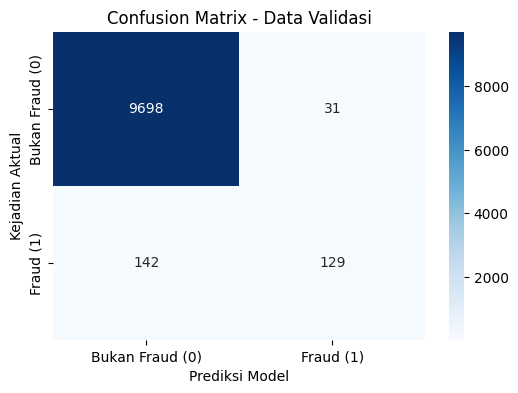

In [ ]:
# --- LANGKAH 5: MODEL TRAINING & EVALUATION ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

print("Sedang melatih model Random Forest... (Tunggu sebentar, mungkin butuh 1-2 menit)")
rf_model.fit(X_train_smote, y_train_smote)
print("Training Selesai!\n")

y_pred = rf_model.predict(X_val)
y_pred_proba = rf_model.predict_proba(X_val)[:, 1]

print("--- HASIL EVALUASI MODEL ---")
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_pred_proba):.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bukan Fraud (0)', 'Fraud (1)'],
            yticklabels=['Bukan Fraud (0)', 'Fraud (1)'])
plt.title('Confusion Matrix - Data Validasi')
plt.xlabel('Prediksi Model')
plt.ylabel('Kejadian Aktual')
plt.show()

In [ ]:
# Prediksi Data Test

file_test_path = '/content/drive/MyDrive/Datasets ML/test_transaction.csv'
df_test = pd.read_csv(file_test_path, nrows=50000)
print(f"Ukuran Data Test Awal: {df_test.shape}")

cols_to_drop_test = [col for col in cols_to_drop if col in df_test.columns]
df_test_clean = df_test.drop(columns=cols_to_drop_test)

num_cols_test = df_test_clean.select_dtypes(include=['int64', 'float64']).columns
num_cols_test = num_cols_test.drop('TransactionID', errors='ignore')
cat_cols_test = df_test_clean.select_dtypes(include=['object']).columns

for col in num_cols_test:
    df_test_clean[col] = df_test_clean[col].fillna(df_train[col].median())

for col in cat_cols_test:
    df_test_clean[col] = df_test_clean[col].fillna(df_train[col].mode()[0])


df_test_encoded = pd.get_dummies(df_test_clean, columns=cat_cols_test, drop_first=True)

X_test = df_test_encoded.drop(columns=['TransactionID', 'TransactionDT'], errors='ignore')

X_test = X_test.reindex(columns=X.columns, fill_value=0)
print(f"Ukuran Fitur Test setelah diselaraskan: {X_test.shape}")

print("\nSedang memprediksi...")
test_pred_proba = rf_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'TransactionID': df_test['TransactionID'],
    'isFraud': test_pred_proba
})

submission.to_csv('submission_uts_ml.csv', index=False)
print("\nBERHASIL! File 'submission_uts_ml.csv' sudah dibuat.")
display(submission.head())

Ukuran Data Test Awal: (50000, 393)
Ukuran Fitur Test setelah diselaraskan: (50000, 263)

Sedang memprediksi...

BERHASIL! File 'submission_uts_ml.csv' sudah dibuat.


,TransactionID,isFraud
0,3663549,0.110941
1,3663550,0.136637
2,3663551,0.135866
3,3663552,0.009499
4,3663553,0.010627
